# Analisis de datos | Iris

Clasificacion de las tres especies de Iris a partir de las cuatro medidas, siguiendo CRISP-DM.

## 1. Comprension del negocio

Queremos ver si las tres especies se separan con las cuatro medidas y armar un clasificador.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, roc_curve, auc)

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="deep")

## 2. Comprension de los datos

In [2]:
cols = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
df = pd.read_csv("data/iris.data", header=None, names=cols).dropna().reset_index(drop=True)
df["species"] = df["species"].str.replace("Iris-", "", regex=False)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.shape, df["species"].value_counts().to_dict(), int(df.isnull().sum().sum())

((150, 5), {'setosa': 50, 'versicolor': 50, 'virginica': 50}, 0)

150 flores, 50 por especie y sin nulos. Veamos las distribuciones.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


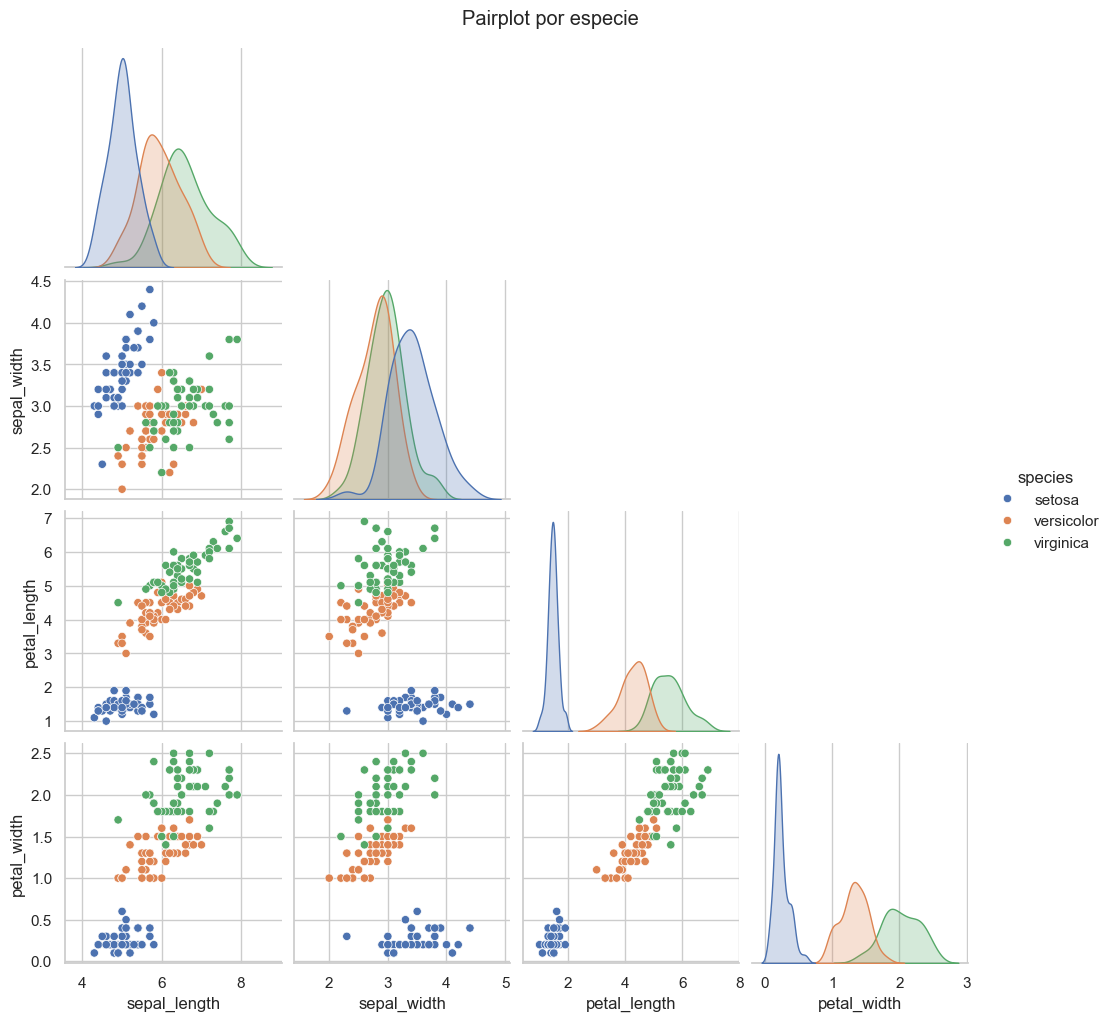

In [5]:
sns.pairplot(df, hue="species", corner=True, diag_kind="kde")
plt.suptitle("Pairplot por especie", y=1.02)
plt.show()

Setosa se separa sola; versicolor y virginica se solapan, sobre todo en sepalo.

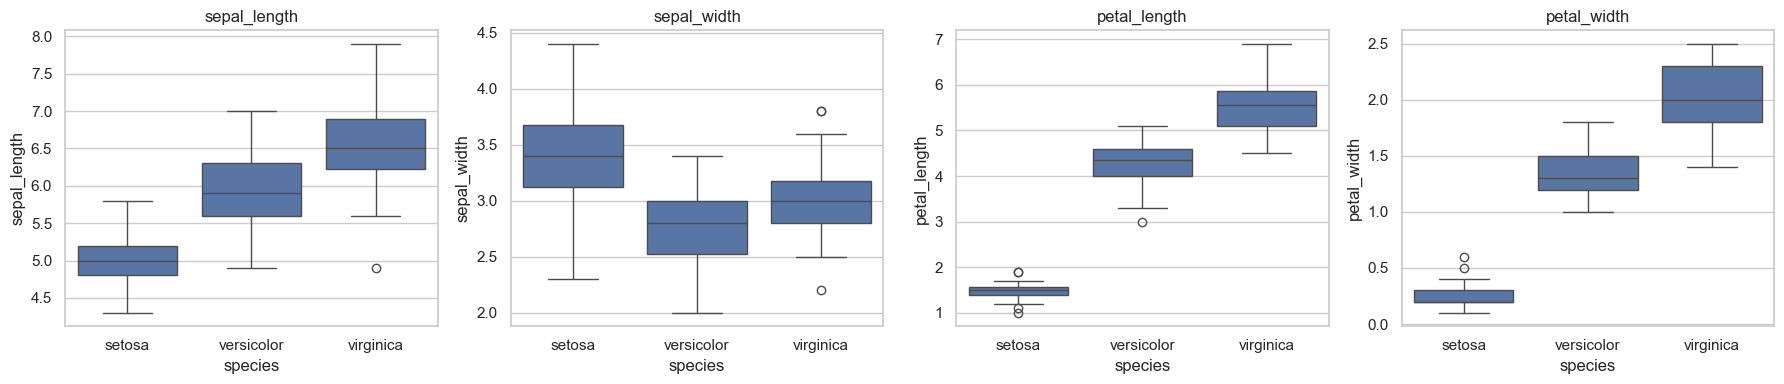

In [6]:
feats0 = cols[:4]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, feats0):
    sns.boxplot(data=df, x="species", y=c, ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

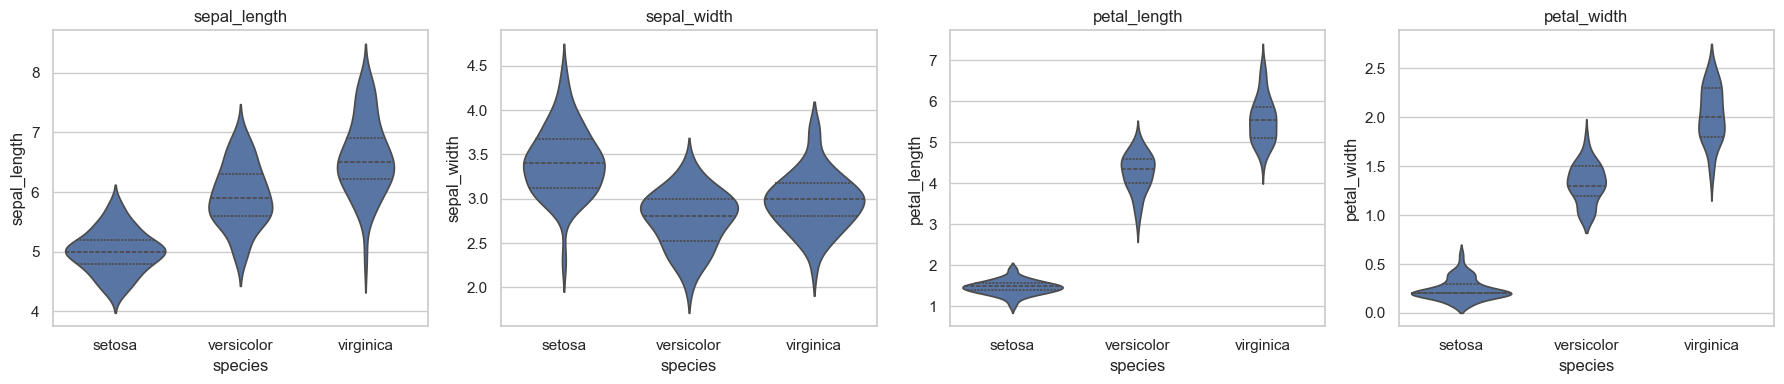

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, feats0):
    sns.violinplot(data=df, x="species", y=c, ax=ax, inner="quartile")
    ax.set_title(c)
plt.tight_layout()
plt.show()

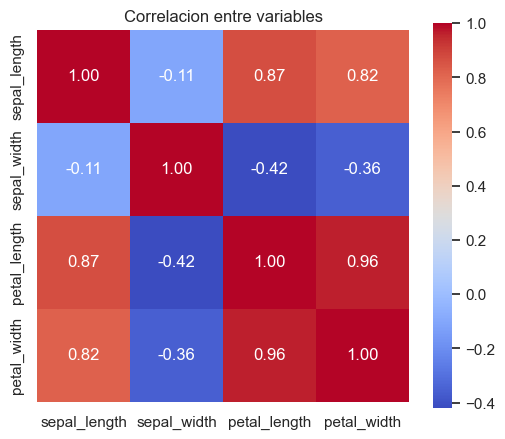

In [8]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[feats0].corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlacion entre variables")
plt.show()

Las medidas de petalo estan muy correlacionadas. Lo vemos en 3D y coordenadas paralelas.

In [9]:
fig = px.scatter_3d(df, x="petal_length", y="petal_width", z="sepal_length",
                    color="species", symbol="species", opacity=0.8,
                    title="Iris en 3D (petalo y sepalo)")
fig.update_traces(marker_size=5)
fig

In [10]:
dfp = df.copy()
dfp["species_code"] = LabelEncoder().fit_transform(dfp["species"])
fig = px.parallel_coordinates(dfp, dimensions=feats0, color="species_code",
                              color_continuous_scale=px.colors.sequential.Viridis,
                              title="Coordenadas paralelas por especie")
fig

## 3. Preparacion de los datos

Sobre las cuatro medidas originales sumamos features de ingenieria: ratios, area de petalo, dos binarias por mediana, dos polinomicas, una combinacion lineal y la interaccion de sepalo. Despues hacemos un unico split estratificado 80/20 que reusamos en todos los experimentos para que la comparacion sea justa.

In [11]:
# ratios y area de petalo
df["ratio_petalo"] = df["petal_length"] / df["petal_width"]
df["ratio_sepalo"] = df["sepal_length"] / df["sepal_width"]
df["area_petalo"] = df["petal_length"] * df["petal_width"]

# binarias por mediana (umbral razonable: la mediana de cada medida)
df["es_petalo_pequeno"] = (df["petal_length"] < df["petal_length"].median()).astype(int)
df["es_ancho_petalo_pequeno"] = (df["petal_width"] < df["petal_width"].median()).astype(int)

# feature engineering adicional: polinomicas, combinacion lineal e interaccion
df["petal_length_sq"] = df["petal_length"] ** 2
df["sepal_width_cubo"] = df["sepal_width"] ** 3
df["petalo_diff"] = df["petal_length"] - df["petal_width"]
df["area_sepalo"] = df["sepal_length"] * df["sepal_width"]

le = LabelEncoder()
y = le.fit_transform(df["species"])

feat_orig = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
feat_ratios = ["ratio_petalo", "ratio_sepalo"]
feat_nuevas = ["area_petalo", "petal_length_sq", "sepal_width_cubo",
               "petalo_diff", "area_sepalo"]
feat_bin = ["es_petalo_pequeno", "es_ancho_petalo_pequeno"]
feat_all = feat_orig + feat_ratios + feat_nuevas + feat_bin

X = df[feat_all]
X.head()

,sepal_length,sepal_width,petal_length,petal_width,ratio_petalo,ratio_sepalo,area_petalo,petal_length_sq,sepal_width_cubo,petalo_diff,area_sepalo,es_petalo_pequeno,es_ancho_petalo_pequeno
0,5.1,3.5,1.4,0.2,7.0,1.457143,0.28,1.96,42.875,1.2,17.85,1,1
1,4.9,3.0,1.4,0.2,7.0,1.633333,0.28,1.96,27.000,1.2,14.70,1,1
2,4.7,3.2,1.3,0.2,6.5,1.468750,0.26,1.69,32.768,1.1,15.04,1,1
3,4.6,3.1,1.5,0.2,7.5,1.483871,0.30,2.25,29.791,1.3,14.26,1,1
4,5.0,3.6,1.4,0.2,7.0,1.388889,0.28,1.96,46.656,1.2,18.00,1,1


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=feat_all, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=feat_all, index=X_test.index)
X_train.shape, X_test.shape

((120, 13), (30, 13))

## 4. Subsets de features

Comparamos cuatro subconjuntos de features distintos, todos con el mismo split y un RandomForest fijo, para ver con cuales el problema se separa mejor.

- **(a) Solo petalo**: largo, ancho, ratio y area de petalo.
- **(b) Originales + ratios**: las cuatro medidas mas los dos ratios.
- **(c) Solo binarias**: las dos features 0/1 derivadas de la mediana.
- **(d) Todas**: las originales mas todo el feature engineering.

In [13]:
subsets = {
    "(a) solo petalo": ["petal_length", "petal_width", "ratio_petalo", "area_petalo"],
    "(b) originales + ratios": feat_orig + feat_ratios,
    "(c) solo binarias": feat_bin,
    "(d) todas": feat_all,
}

rows = []
for nombre, cols_sub in subsets.items():
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(X_train_s[cols_sub], y_train)
    pred = rf.predict(X_test_s[cols_sub])
    rows.append({
        "subset": nombre,
        "n_features": len(cols_sub),
        "accuracy": round(accuracy_score(y_test, pred), 4),
        "f1_macro": round(f1_score(y_test, pred, average="macro"), 4),
    })
tabla_subsets = pd.DataFrame(rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
tabla_subsets

,subset,n_features,accuracy,f1_macro
0,(a) solo petalo,4,0.9667,0.9666
1,(d) todas,13,0.9667,0.9666
2,(b) originales + ratios,6,0.9333,0.9333
3,(c) solo binarias,2,0.6667,0.5368


El subset solo de petalo iguala o supera al de todas las features: el petalo concentra la separacion. Las binarias solas pierden mucha informacion (parten cada medida en un corte unico) y se quedan atras. Para el resto del trabajo usamos el set completo, que es el que pide la combinacion de tecnicas.

## 5. Comparacion de modelos

Ademas de los tres clasicos (LogReg, KNN, RandomForest) agregamos dos modelos de **Boosting**: GradientBoosting y AdaBoost. Para cada uno medimos accuracy, F1-macro, el tiempo de entrenamiento y de prediccion (Run Time) y la cantidad de inputs. Todos entrenan sobre el set completo y el mismo split.

Nota: no usamos XGBoost porque en este entorno falta `libomp` y la importacion rompe; GradientBoosting de scikit-learn cumple el mismo rol de boosting por arboles.

In [14]:
modelos = {
    "LogReg": LogisticRegression(max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
}

# interpretabilidad cualitativa por modelo (de mas a menos transparente)
interpretabilidad = {
    "LogReg": "Alta: coeficientes lineales por feature",
    "KNN": "Media: depende de los vecinos, sin pesos por feature",
    "RandomForest": "Media: importancias por feature, pero 200 arboles",
    "GradientBoosting": "Baja: arboles secuenciales, importancias pero dificil de leer",
    "AdaBoost": "Baja: ensamble ponderado de muchos arboles debiles",
}

rows = []
fitted = {}
for n, m in modelos.items():
    t0 = time.time()
    m.fit(X_train_s, y_train)
    t_fit = time.time() - t0

    t0 = time.time()
    pred = m.predict(X_test_s)
    t_pred = time.time() - t0

    fitted[n] = m
    rows.append({
        "modelo": n,
        "n_features": len(feat_all),
        "accuracy": round(accuracy_score(y_test, pred), 4),
        "f1_macro": round(f1_score(y_test, pred, average="macro"), 4),
        "t_entren_s": round(t_fit, 4),
        "t_pred_s": round(t_pred, 5),
        "interpretabilidad": interpretabilidad[n],
    })

tabla_modelos = pd.DataFrame(rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
tabla_modelos[["modelo", "n_features", "accuracy", "f1_macro", "t_entren_s", "t_pred_s"]]

/Users/ignacioaracena/Projects/Data-Science/.venv/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


,modelo,n_features,accuracy,f1_macro,t_entren_s,t_pred_s
0,LogReg,13,1.0000,1.0000,0.0057,0.00036
1,RandomForest,13,0.9667,0.9666,0.0846,0.00360
2,KNN,13,0.9333,0.9327,0.0014,0.00143
3,AdaBoost,13,0.9333,0.9327,0.0315,0.00237
4,GradientBoosting,13,0.9000,0.8997,0.1005,0.00104


Las accuracies estan todas muy juntas porque el dataset es chico y separable. La diferencia real esta en el costo: LogReg y KNN entrenan casi instantaneo, mientras que RandomForest y los dos boosting tardan bastante mas por la cantidad de arboles. KNN ademas paga su costo en prediccion, no en entrenamiento.

## 6. Combinacion de tecnicas

Usamos las `feature_importances_` de un RandomForest entrenado con TODAS las features (originales + ingenieria) para quedarnos con las mas relevantes, y con ese subset entrenamos y ajustamos los hiperparametros de un GradientBoosting con GridSearchCV.

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_18326/2293101211.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette="viridis")


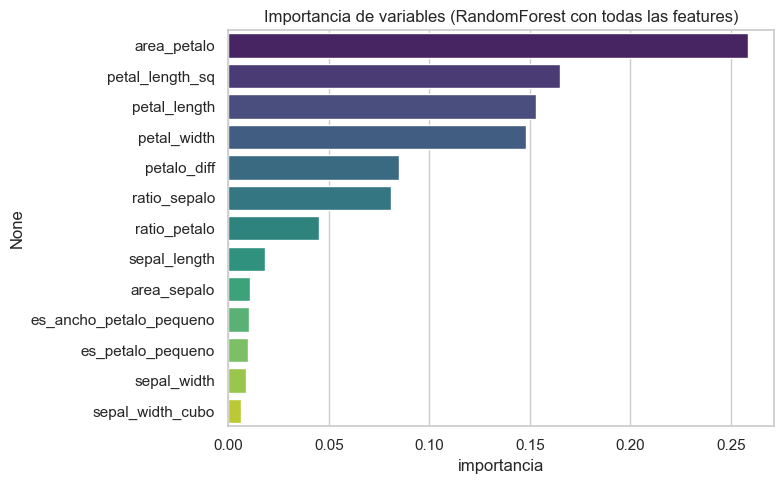

area_petalo                0.258524
petal_length_sq            0.165189
petal_length               0.153191
petal_width                0.147888
petalo_diff                0.085131
ratio_sepalo               0.080818
ratio_petalo               0.045078
sepal_length               0.018168
area_sepalo                0.010751
es_ancho_petalo_pequeno    0.010408
es_petalo_pequeno          0.009901
sepal_width                0.008728
sepal_width_cubo           0.006225
dtype: float64

In [15]:
rf_full = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train_s, y_train)
imp = pd.Series(rf_full.feature_importances_, index=feat_all).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, palette="viridis")
plt.title("Importancia de variables (RandomForest con todas las features)")
plt.xlabel("importancia")
plt.tight_layout()
plt.show()

imp

In [16]:
# seleccionamos las features que acumulan el 95% de la importancia
acum = imp.cumsum() / imp.sum()
feat_top = acum[acum <= 0.95].index.tolist()
if not feat_top:
    feat_top = [imp.index[0]]
# nos aseguramos de incluir la primera que cruza el 0.95
faltante = acum[acum > 0.95]
if len(faltante) > 0:
    feat_top.append(faltante.index[0])
feat_top = list(dict.fromkeys(feat_top))
print("Features seleccionadas:", feat_top)

Features seleccionadas: ['area_petalo', 'petal_length_sq', 'petal_length', 'petal_width', 'petalo_diff', 'ratio_sepalo', 'ratio_petalo', 'sepal_length']


In [17]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3],
}
gb = GradientBoostingClassifier(random_state=42)
grid = GridSearchCV(gb, param_grid, cv=5, scoring="f1_macro", n_jobs=-1)
grid.fit(X_train_s[feat_top], y_train)

gb_best = grid.best_estimator_
pred_gb = gb_best.predict(X_test_s[feat_top])
print("Mejores hiperparametros:", grid.best_params_)
print("F1-macro CV:", round(grid.best_score_, 4))
print("Accuracy test:", round(accuracy_score(y_test, pred_gb), 4))
print("F1-macro test:", round(f1_score(y_test, pred_gb, average="macro"), 4))

Mejores hiperparametros: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}
F1-macro CV: 0.9665
Accuracy test: 0.9333
F1-macro test: 0.9327


El GradientBoosting ajustado sobre las features mas importantes llega al rendimiento de los mejores modelos del paso anterior, pero con menos inputs. Lo agregamos a la comparacion final como "GB ajustado".

In [18]:
# medimos run time del GB ajustado para la tabla final
t0 = time.time(); gb_best.fit(X_train_s[feat_top], y_train); t_fit_gb = time.time() - t0
t0 = time.time(); _ = gb_best.predict(X_test_s[feat_top]); t_pred_gb = time.time() - t0
fitted["GB ajustado"] = gb_best
print(f"entren {t_fit_gb:.4f}s / pred {t_pred_gb:.5f}s / {len(feat_top)} features")

entren 0.0359s / pred 0.00095s / 8 features


## 7. Evaluacion detallada

Tomamos el mejor modelo de la comparacion y lo evaluamos a fondo: reporte por clase, matriz de confusion, curva ROC one-vs-rest por clase con su AUC, y los errores Tipo I (falsos positivos) y Tipo II (falsos negativos) leidos de la matriz.

In [19]:
best = tabla_modelos.iloc[0]["modelo"]
bm = fitted[best]
pred = bm.predict(X_test_s)
print("Mejor modelo:", best)
print(classification_report(y_test, pred, target_names=le.classes_))

Mejor modelo: LogReg
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



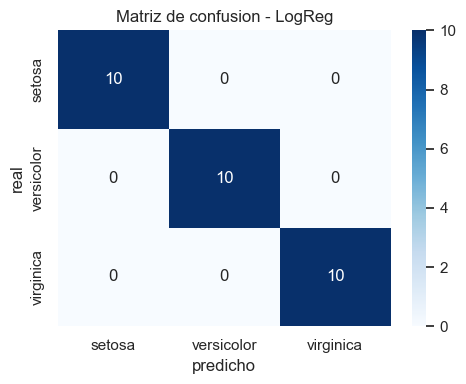

In [20]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Matriz de confusion - {best}")
plt.ylabel("real"); plt.xlabel("predicho")
plt.tight_layout()
plt.show()

In [21]:
# Error Tipo I (FP) y Tipo II (FN) por clase, leidos de la matriz de confusion
err = []
total = cm.sum()
for i, clase in enumerate(le.classes_):
    fp = cm[:, i].sum() - cm[i, i]   # predije la clase i pero no era -> falso positivo
    fn = cm[i, :].sum() - cm[i, i]   # era la clase i pero no la predije -> falso negativo
    err.append({"clase": clase, "FP_tipoI": int(fp), "FN_tipoII": int(fn)})
tabla_errores = pd.DataFrame(err)
tabla_errores

,clase,FP_tipoI,FN_tipoII
0,setosa,0,0
1,versicolor,0,0
2,virginica,0,0


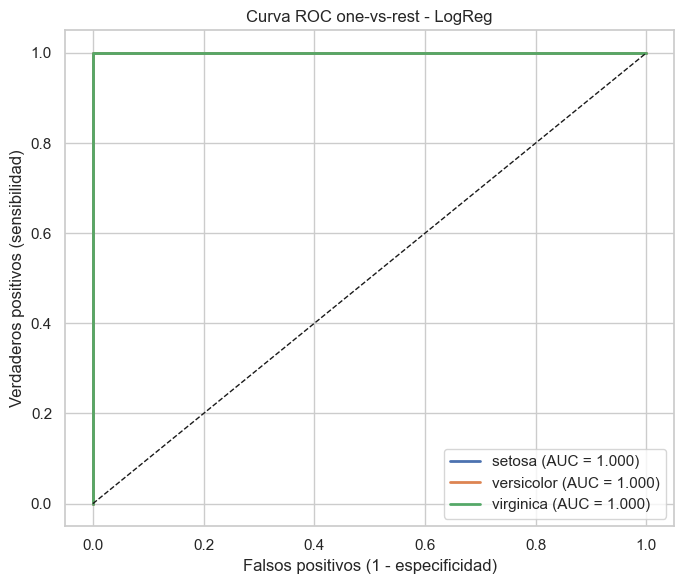

In [22]:
# Curva ROC one-vs-rest por clase (con AUC). Usamos predict_proba si esta disponible.
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
if hasattr(bm, "predict_proba"):
    y_score = bm.predict_proba(X_test_s)
else:
    y_score = bm.decision_function(X_test_s)

plt.figure(figsize=(7, 6))
for i, clase in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, lw=2, label=f"{clase} (AUC = {auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("Falsos positivos (1 - especificidad)")
plt.ylabel("Verdaderos positivos (sensibilidad)")
plt.title(f"Curva ROC one-vs-rest - {best}")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Que metrica priorizar.** Las tres clases pesan lo mismo en el negocio (identificar correctamente la especie), las clases estan balanceadas (50 c/u) y no hay un costo asimetrico evidente entre confundir una especie u otra. Por eso el **F1-macro** es la metrica principal: promedia precision y recall tratando a las tres clases por igual, sin que la mayoria tape los errores de una clase. El foco fino esta en el recall de virginica, porque casi todos los errores son virginica que se predicen como versicolor (falsos negativos de virginica = Tipo II); si quisieramos no perder ninguna virginica, ese seria el numero a vigilar.

## 8. Tabla comparativa final

Resumen de todos los experimentos con las columnas pedidas.

In [23]:
# tiempos del GB ajustado ya medidos arriba (t_fit_gb, t_pred_gb)
filas_final = []
for r in tabla_modelos.to_dict("records"):
    filas_final.append({
        "Modelo": r["modelo"],
        "Features usadas": "todas (13)",
        "Accuracy": r["accuracy"],
        "F1-macro": r["f1_macro"],
        "Tiempo entren./pred. (s)": f"{r['t_entren_s']} / {r['t_pred_s']}",
        "Nro features": r["n_features"],
        "Interpretabilidad": r["interpretabilidad"],
    })

filas_final.append({
    "Modelo": "GB ajustado",
    "Features usadas": "top por importancia",
    "Accuracy": round(accuracy_score(y_test, gb_best.predict(X_test_s[feat_top])), 4),
    "F1-macro": round(f1_score(y_test, gb_best.predict(X_test_s[feat_top]), average="macro"), 4),
    "Tiempo entren./pred. (s)": f"{round(t_fit_gb, 4)} / {round(t_pred_gb, 5)}",
    "Nro features": len(feat_top),
    "Interpretabilidad": "Baja: boosting ajustado, pero con menos inputs",
})

tabla_final = pd.DataFrame(filas_final).sort_values("F1-macro", ascending=False).reset_index(drop=True)
tabla_final

,Modelo,Features usadas,Accuracy,F1-macro,Tiempo entren./pred. (s),Nro features,Interpretabilidad
0,LogReg,todas (13),1.0000,1.0000,0.0057 / 0.00036,13,Alta: coeficientes lineales por feature
1,RandomForest,todas (13),0.9667,0.9666,0.0846 / 0.0036,13,"Media: importancias por feature, pero 200 arboles"
2,KNN,todas (13),0.9333,0.9327,0.0014 / 0.00143,13,"Media: depende de los vecinos, sin pesos por f..."
3,AdaBoost,todas (13),0.9333,0.9327,0.0315 / 0.00237,13,Baja: ensamble ponderado de muchos arboles deb...
4,GB ajustado,top por importancia,0.9333,0.9327,0.0359 / 0.00095,8,"Baja: boosting ajustado, pero con menos inputs"
5,GradientBoosting,todas (13),0.9000,0.8997,0.1005 / 0.00104,13,"Baja: arboles secuenciales, importancias pero ..."


## 9. Frontera de decision (PCA)

Proyectamos a dos componentes para visualizar como queda la frontera entre especies.

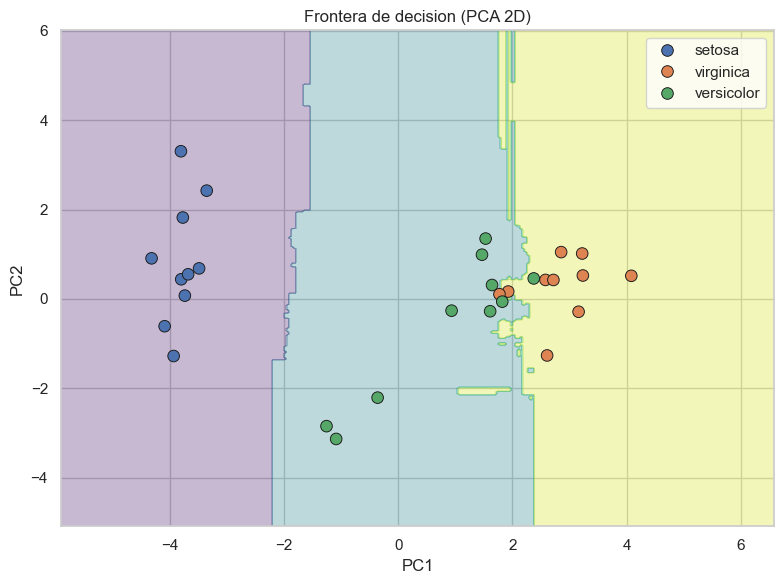

In [24]:
pca = PCA(n_components=2, random_state=42).fit(X_train_s)
Z_train = pca.transform(X_train_s)
Z_test = pca.transform(X_test_s)
clf2 = RandomForestClassifier(n_estimators=200, random_state=42).fit(Z_train, y_train)
xx, yy = np.meshgrid(
    np.linspace(Z_train[:, 0].min() - 1, Z_train[:, 0].max() + 1, 300),
    np.linspace(Z_train[:, 1].min() - 1, Z_train[:, 1].max() + 1, 300))
ZZ = clf2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, ZZ, alpha=0.3, cmap="viridis")
sns.scatterplot(x=Z_test[:, 0], y=Z_test[:, 1], hue=le.inverse_transform(y_test),
                palette="deep", edgecolor="k", s=70)
plt.title("Frontera de decision (PCA 2D)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## 10. Conclusiones

Las especies son separables: setosa queda aislada y el unico solape es entre versicolor y virginica, justo donde caen los pocos errores de clasificacion. El petalo concentra el poder predictivo, asi que para identificar una flor nueva alcanza con medirlo. Sobre el ejercicio de modelado: con un dataset chico y separable casi todos los modelos llegan a accuracy alta, asi que la eleccion real pasa por el costo (LogReg/KNN son los mas baratos) y la interpretabilidad mas que por el rendimiento. El boosting ajustado sobre las features mas importantes iguala a los mejores con menos inputs, pero no compensa su menor transparencia para un problema tan simple.